<a href="https://colab.research.google.com/github/jigarpatel18/programming-projects/blob/main/CS108_STAT108_W26_Final_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS108/212 STAT108/212 W26 Course Project

### Team Details

- Teammate 1: Shashwat Jha (sjha013)
- Teammate 2: Vishvaditya Luhach (vluha001)
- Teammate 3: Jigar Patel (jpate128)

---

# Installs

In [ ]:
# Install necessary packages
!pip install aif360 --quiet
!pip install 'aif360[Reductions]' --quiet
!pip install fairlearn --quiet
!pip install ucimlrepo --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 23.4 MB/s eta 0:00:00


# Imports

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import collections
import warnings
warnings.filterwarnings('ignore')
from pprint import pprint
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# AIF360 imports
from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.preprocessing import Reweighing
from aif360.algorithms.inprocessing import PrejudiceRemover
from aif360.algorithms.postprocessing import RejectOptionClassification
from aif360.metrics import BinaryLabelDatasetMetric, ClassificationMetric

pip install 'aif360[inFairness]'


# Loading dataset
_(same as previous milestone, copy-paste)_

In [ ]:
# Load the German Credit dataset from UCI
from ucimlrepo import fetch_ucirepo

statlog_german_credit_data = fetch_ucirepo(id=144)
raw_df = statlog_german_credit_data.data.original.copy()

# The dataset uses numeric codes; map column names for clarity
# Column 'Attribute9' is personal status/sex (sensitive: gender)
# Column 'Attribute13' is age (sensitive)
# Target column is 'class' (1 = good credit, 2 = bad credit)

# We use age as the primary sensitive feature (as per proposal)
# Binarize age: 0 = young (< 25), 1 = older (>= 25)
sensitive_feature_colname = 'age_group'
raw_df[sensitive_feature_colname] = (raw_df['Attribute13'] >= 25).astype(int)

# Encode target: 1 (good) -> 1, 2 (bad) -> 0
raw_df['target'] = (raw_df['class'] == 1).astype(int)

# Separate features, target, and group labels
drop_cols = ['class', 'target', sensitive_feature_colname]
X = raw_df.drop(columns=drop_cols)
y = raw_df['target']
group_labels = raw_df[sensitive_feature_colname]

# Print some stats
print(f"No. of samples: {X.shape[0]}")
print(f"No. of features: {X.shape[1]}")
print(f"Group Counts: {dict(collections.Counter(group_labels))}")
print(f"Target Distribution: {dict(collections.Counter(y))}")
print(f"\nGroup 0 = Young (age < 25), Group 1 = Older (age >= 25)")

No. of samples: 1000
No. of features: 20
Group Counts: {1: 851, 0: 149}
Target Distribution: {1: 700, 0: 300}

Group 0 = Young (age < 25), Group 1 = Older (age >= 25)


# Preparing dataset
_(same as previous milestone, copy-paste)_

In [ ]:
# Dataset preparation steps:
# 1. Handle missing data (none expected in German Credit, but check)
# 2. Encode categorical features
# 3. Normalize numerical features

# Step 1: Check for missing values
print(f"Missing values before cleaning: {X.isnull().sum().sum()}")

# Step 2: Encode categorical features using LabelEncoder
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Categorical columns to encode: {cat_cols}")

le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col].astype(str))

# Step 3: Normalize numerical features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
X = X_scaled

# Reset indices to align properly
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)
group_labels = group_labels.reset_index(drop=True)

print(f"No. of samples AFTER cleaning: {X.shape[0]}")
assert X.shape[0] == y.shape[0] == group_labels.shape[0]
print(f"No. of features AFTER encoding: {X.shape[1]}")

Missing values before cleaning: 0
Categorical columns to encode: ['Attribute1', 'Attribute3', 'Attribute4', 'Attribute6', 'Attribute7', 'Attribute9', 'Attribute10', 'Attribute12', 'Attribute14', 'Attribute15', 'Attribute17', 'Attribute19', 'Attribute20']
No. of samples AFTER cleaning: 1000
No. of features AFTER encoding: 20


# Getting training and testing sets

Note: Train-test split is made **ONCE** to obtain the _training set_ and the _testing set_ and every teammate will use the training set to train their baseline model and test the trained model using the testing set. **NEVER** modify the testing set once it has been created.
Therefore, the following code cell does not need to be edited.

_(same as previous milestone, copy-paste)_

In [ ]:
X_train, X_test, \
  y_train, y_test, \
    group_labels_train, group_labels_test = train_test_split(X, y, group_labels,
                                                             test_size=0.2, random_state=42)

print(f"No. of training samples: {X_train.shape[0]}")
print(f"No. of testing samples: {X_test.shape[0]}")

# Delete X, y and group_label variables to make sure they are not used later on.
del X
del y
del group_labels

No. of training samples: 800
No. of testing samples: 200


# Exploratory Data Analysis (EDA)

Before training any models, we conduct an in-depth exploration of the German Credit dataset to understand the data distributions, identify pre-existing bias signals, and examine how the sensitive feature (age group) relates to credit outcomes.

The dataset contains **1,000 samples** and **20 features** covering financial history, employment, demographics, and loan details. The target variable is binary credit risk (Good=700 / Bad=300). The sensitive feature is **age**, binarized as Young (<25, n=149) and Older (≥25, n=851).

In [ ]:
# EDA 1: Dataset Overview
eda_df = raw_df.copy()
eda_df['credit_risk']     = eda_df['class'].map({1: 'Good Credit', 2: 'Bad Credit'})
eda_df['age_group_label'] = eda_df['age_group'].map({0: 'Young (<25)', 1: 'Older (≥25)'})

print("Dataset Shape:", eda_df.shape)
print("\nClass Distribution:")
print(eda_df['credit_risk'].value_counts())
print("\nAge Group Distribution:")
print(eda_df['age_group_label'].value_counts())
print("\nAge (Attribute13) Stats:")
print(eda_df['Attribute13'].describe().round(2))

Dataset Shape: (1000, 25)

Class Distribution:
credit_risk
Good Credit    700
Bad Credit     300
Name: count, dtype: int64

Age Group Distribution:
age_group_label
Older (≥25)    851
Young (<25)    149
Name: count, dtype: int64

Age (Attribute13) Stats:
count    1000.00
mean       35.55
std        11.38
min        19.00
25%        27.00
50%        33.00
75%        42.00
max        75.00
Name: Attribute13, dtype: float64


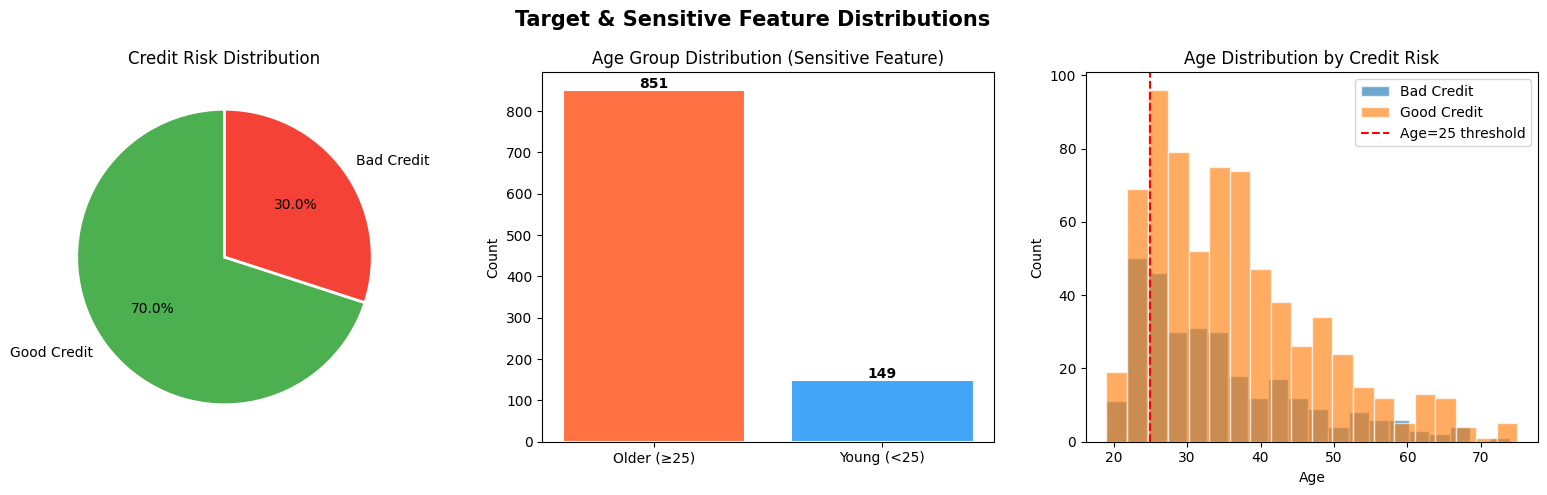

In [ ]:
# EDA 2: Target & Sensitive Feature Distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Target & Sensitive Feature Distributions', fontsize=15, fontweight='bold')

# Credit risk pie
counts = eda_df['credit_risk'].value_counts()
axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=['#4CAF50','#F44336'], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Credit Risk Distribution')

# Age group bar
age_c = eda_df['age_group_label'].value_counts()
bars = axes[1].bar(age_c.index, age_c.values, color=['#FF7043','#42A5F5'], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, age_c.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5, str(val), ha='center', fontweight='bold')
axes[1].set_title('Age Group Distribution (Sensitive Feature)'); axes[1].set_ylabel('Count')

# Age histogram by credit risk
for label, grp in eda_df.groupby('credit_risk'):
    axes[2].hist(grp['Attribute13'], bins=20, alpha=0.65, label=label, edgecolor='white')
axes[2].axvline(25, color='red', linestyle='--', linewidth=1.5, label='Age=25 threshold')
axes[2].set_xlabel('Age'); axes[2].set_ylabel('Count')
axes[2].set_title('Age Distribution by Credit Risk'); axes[2].legend()
plt.tight_layout(); plt.show()

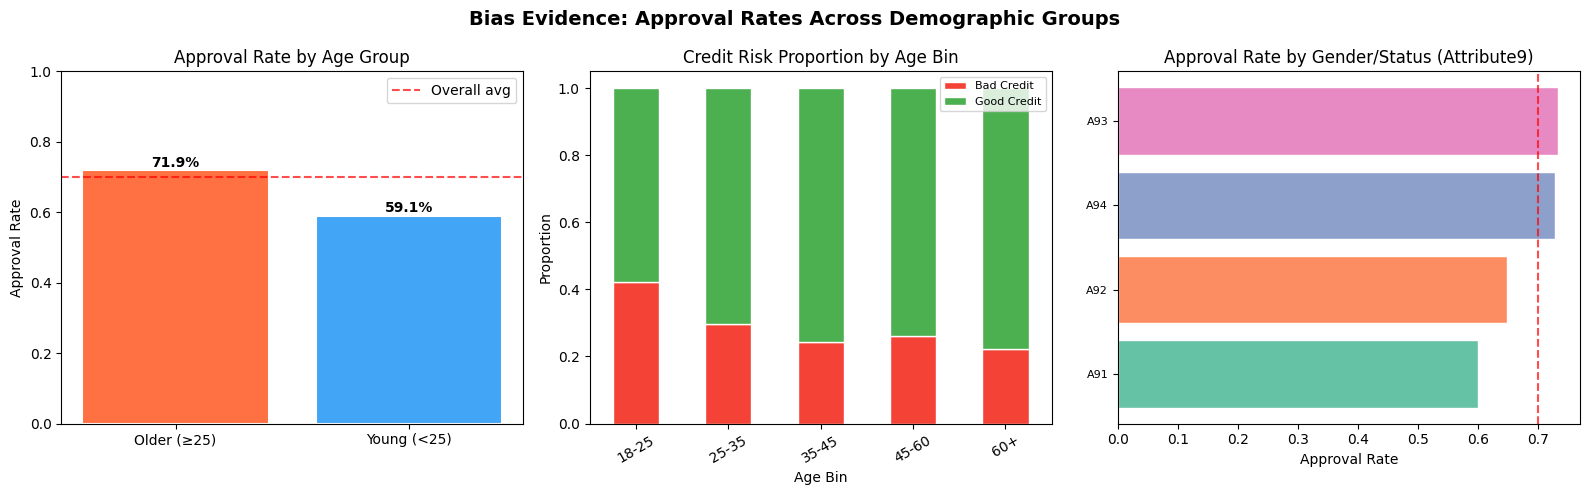

Raw Dataset Approval Rates:
  Young (<25):  0.591
  Older (>=25): 0.719
  SPD (raw):    -0.129  (negative = young disadvantaged)
  DI (raw):     0.821  (<0.8 = disparate impact present)


In [ ]:
# EDA 3: Bias Evidence — Approval Rates Across Groups
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Bias Evidence: Approval Rates Across Demographic Groups', fontsize=14, fontweight='bold')

# 1) Approval rate by age group
age_approval = eda_df.groupby('age_group_label')['target'].mean().reset_index()
age_approval.columns = ['Age Group','Approval Rate']
bars = axes[0].bar(age_approval['Age Group'], age_approval['Approval Rate'],
                   color=['#FF7043','#42A5F5'], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, age_approval['Approval Rate']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{val:.1%}', ha='center', fontweight='bold')
axes[0].set_ylim(0,1); axes[0].set_ylabel('Approval Rate')
axes[0].set_title('Approval Rate by Age Group')
axes[0].axhline(eda_df['target'].mean(), color='red', linestyle='--', alpha=0.7, label='Overall avg')
axes[0].legend()

# 2) Stacked bar by age bin
age_bins = pd.cut(eda_df['Attribute13'], bins=[18,25,35,45,60,100], labels=['18-25','25-35','35-45','45-60','60+'])
eda_df['age_bin'] = age_bins
abin = eda_df.groupby(['age_bin','credit_risk']).size().unstack(fill_value=0)
abin_pct = abin.div(abin.sum(axis=1), axis=0)
abin_pct.plot(kind='bar', stacked=True, ax=axes[1], color=['#F44336','#4CAF50'], edgecolor='white')
axes[1].set_xlabel('Age Bin'); axes[1].set_ylabel('Proportion')
axes[1].set_title('Credit Risk Proportion by Age Bin'); axes[1].tick_params(axis='x', rotation=30); axes[1].legend(fontsize=8)

# 3) Approval by gender/status (Attribute9)
gen_app = eda_df.groupby('Attribute9')['target'].agg(['mean','count']).reset_index()
gen_app.columns=['Gender/Status','Approval Rate','Count']
gen_app = gen_app[gen_app['Count']>=10].sort_values('Approval Rate')
axes[2].barh(range(len(gen_app)), gen_app['Approval Rate'],
             color=sns.color_palette('Set2',len(gen_app)), edgecolor='white')
axes[2].set_yticks(range(len(gen_app))); axes[2].set_yticklabels(gen_app['Gender/Status'], fontsize=8)
axes[2].set_xlabel('Approval Rate'); axes[2].set_title('Approval Rate by Gender/Status (Attribute9)')
axes[2].axvline(eda_df['target'].mean(), color='red', linestyle='--', alpha=0.7)

plt.tight_layout(); plt.show()

young_app = eda_df[eda_df['age_group_label']=='Young (<25)']['target'].mean()
old_app   = eda_df[eda_df['age_group_label']=='Older (≥25)']['target'].mean()
print(f"Raw Dataset Approval Rates:")
print(f"  Young (<25):  {young_app:.3f}")
print(f"  Older (>=25): {old_app:.3f}")
print(f"  SPD (raw):    {young_app-old_app:.3f}  (negative = young disadvantaged)")
print(f"  DI (raw):     {young_app/old_app:.3f}  (<0.8 = disparate impact present)")

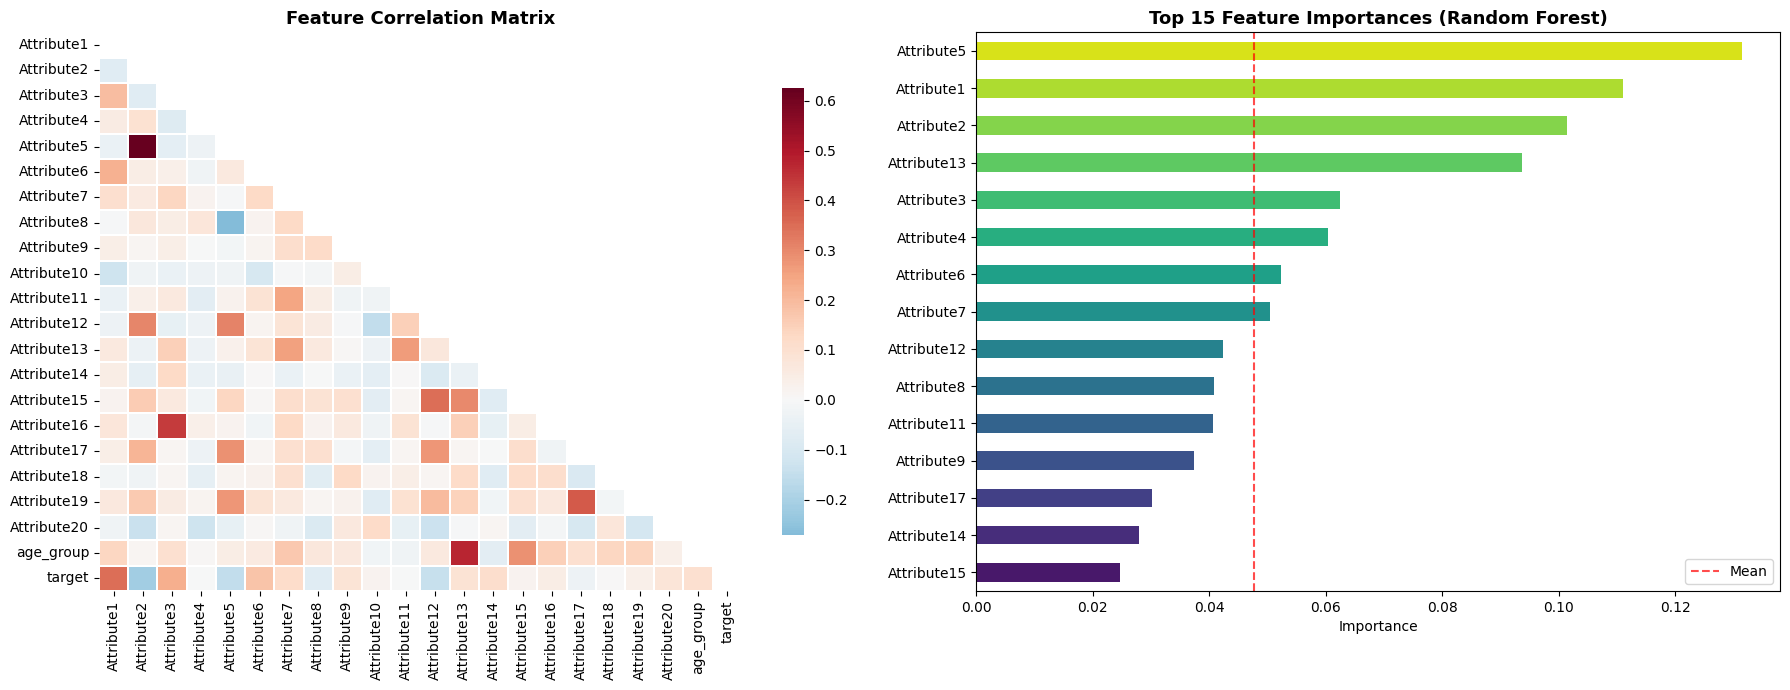

Top 5 most important features:
  Attribute5: 0.1314
  Attribute1: 0.1110
  Attribute2: 0.1015
  Attribute13: 0.0936
  Attribute3: 0.0624


In [ ]:
# EDA 4: Feature Correlation Matrix & Random Forest Feature Importances
eda_X_raw = raw_df.drop(columns=['class','target','age_group'])
from sklearn.preprocessing import LabelEncoder as LE
eda_X_enc = eda_X_raw.copy()
le_eda = LE()
for col in eda_X_enc.select_dtypes(include=['object','category']).columns:
    eda_X_enc[col] = le_eda.fit_transform(eda_X_enc[col].astype(str))
eda_X_enc['age_group'] = raw_df['age_group'].values
eda_X_enc['target']    = raw_df['target'].values

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

corr = eda_X_enc.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, annot=False,
            linewidths=0.3, ax=axes[0], cbar_kws={'shrink':0.8})
axes[0].set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')

from sklearn.ensemble import RandomForestClassifier as RFC
rf_eda = RFC(n_estimators=100, random_state=42)
feat_cols = [c for c in eda_X_enc.columns if c != 'target']
rf_eda.fit(eda_X_enc[feat_cols], eda_X_enc['target'])
importances = pd.Series(rf_eda.feature_importances_, index=feat_cols).sort_values(ascending=True)
importances.tail(15).plot(kind='barh', ax=axes[1], color=sns.color_palette('viridis',15))
axes[1].set_title('Top 15 Feature Importances (Random Forest)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Importance')
axes[1].axvline(importances.mean(), color='red', linestyle='--', alpha=0.7, label='Mean')
axes[1].legend()
plt.tight_layout(); plt.show()

print("Top 5 most important features:")
for feat, imp in importances.tail(5)[::-1].items():
    print(f"  {feat}: {imp:.4f}")

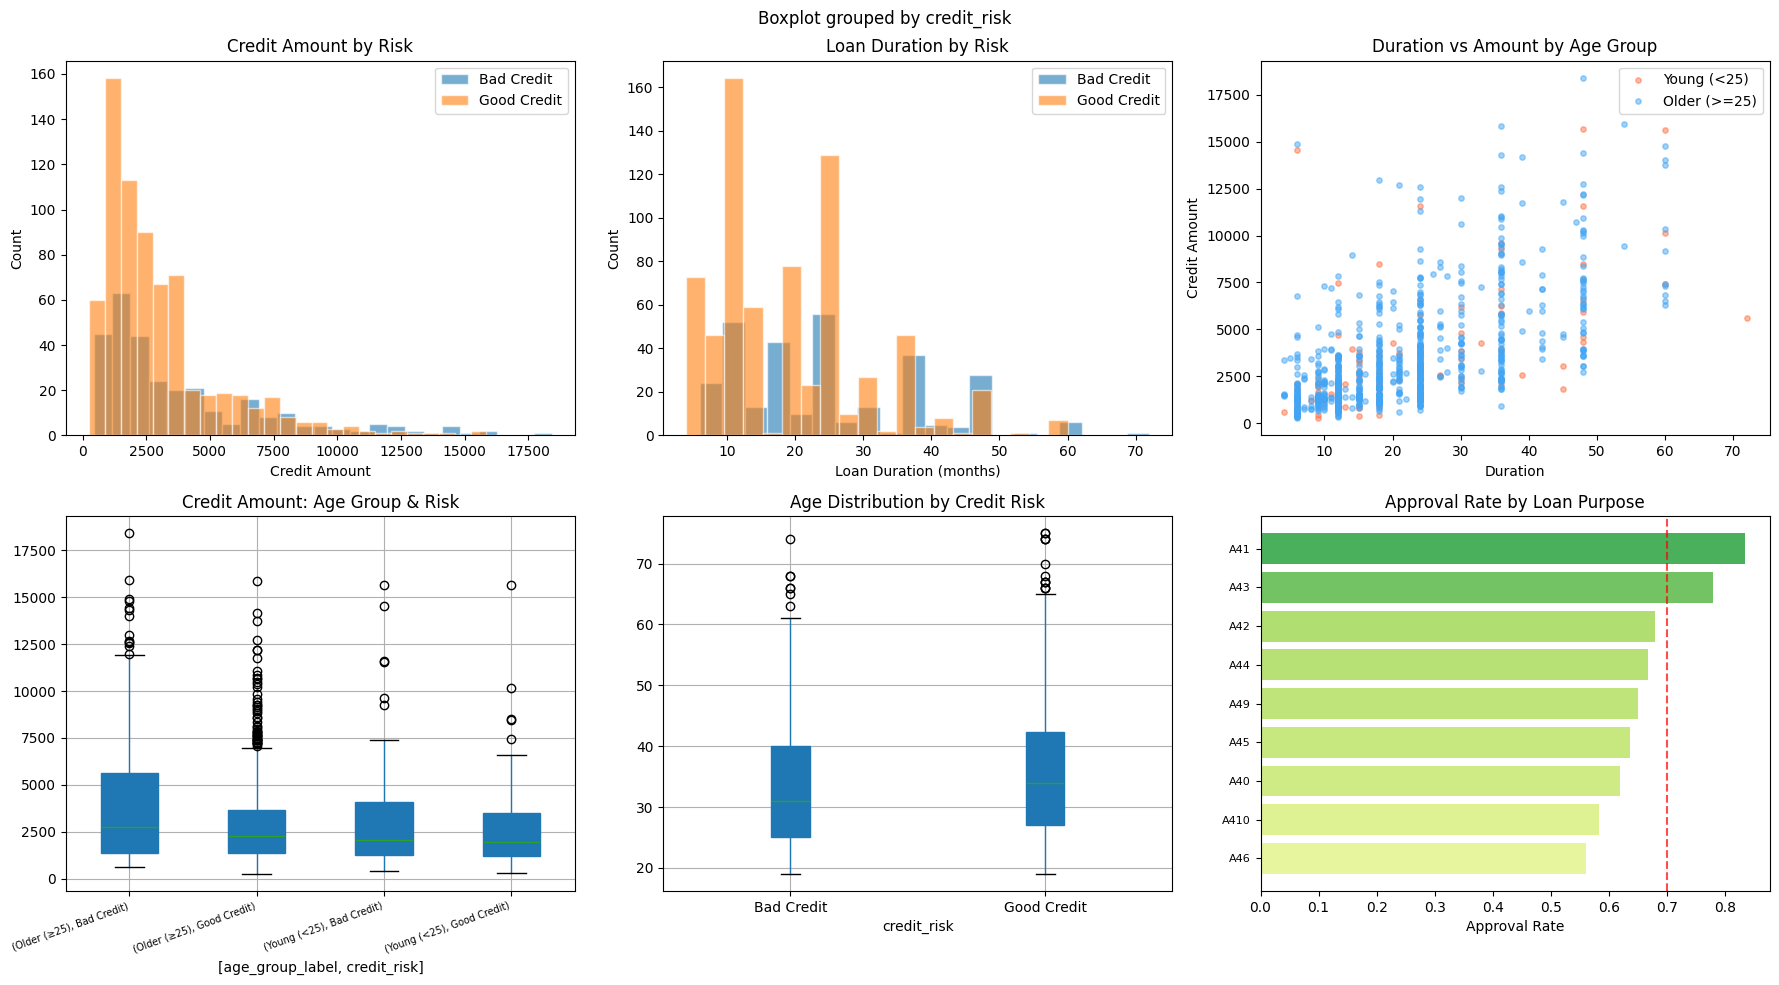

In [ ]:
# EDA 5: Financial Features Deep-Dive (Credit Amount, Duration, Loan Purpose)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Financial Feature Deep-Dive', fontsize=15, fontweight='bold')

for label, grp in eda_df.groupby('credit_risk'):
    axes[0,0].hist(grp['Attribute5'], bins=25, alpha=0.6, label=label, edgecolor='white')
axes[0,0].set_xlabel('Credit Amount'); axes[0,0].set_ylabel('Count')
axes[0,0].set_title('Credit Amount by Risk'); axes[0,0].legend()

for label, grp in eda_df.groupby('credit_risk'):
    axes[0,1].hist(grp['Attribute2'], bins=20, alpha=0.6, label=label, edgecolor='white')
axes[0,1].set_xlabel('Loan Duration (months)'); axes[0,1].set_ylabel('Count')
axes[0,1].set_title('Loan Duration by Risk'); axes[0,1].legend()

for g, color in [(0,'#FF7043'),(1,'#42A5F5')]:
    s = eda_df[eda_df['age_group']==g]
    axes[0,2].scatter(s['Attribute2'], s['Attribute5'], alpha=0.5, s=15, color=color,
                      label='Young (<25)' if g==0 else 'Older (>=25)')
axes[0,2].set_xlabel('Duration'); axes[0,2].set_ylabel('Credit Amount')
axes[0,2].set_title('Duration vs Amount by Age Group'); axes[0,2].legend()

eda_df.boxplot(column='Attribute5', by=['age_group_label','credit_risk'], ax=axes[1,0], patch_artist=True)
axes[1,0].set_title('Credit Amount: Age Group & Risk'); plt.sca(axes[1,0]); plt.xticks(rotation=20,ha='right',fontsize=7)

eda_df.boxplot(column='Attribute13', by='credit_risk', ax=axes[1,1], patch_artist=True)
axes[1,1].set_title('Age Distribution by Credit Risk')

purpose_app = eda_df.groupby('Attribute4')['target'].agg(['mean','count'])
purpose_app = purpose_app[purpose_app['count']>=10].sort_values('mean')
axes[1,2].barh(range(len(purpose_app)), purpose_app['mean'],
               color=plt.cm.RdYlGn(purpose_app['mean'].values))
axes[1,2].set_yticks(range(len(purpose_app))); axes[1,2].set_yticklabels(purpose_app.index, fontsize=8)
axes[1,2].set_xlabel('Approval Rate'); axes[1,2].set_title('Approval Rate by Loan Purpose')
axes[1,2].axvline(eda_df['target'].mean(), color='red', linestyle='--', alpha=0.7)

plt.tight_layout(); plt.show()

Computing 3D t-SNE (perplexity=40, 1000 iterations)...
Done.


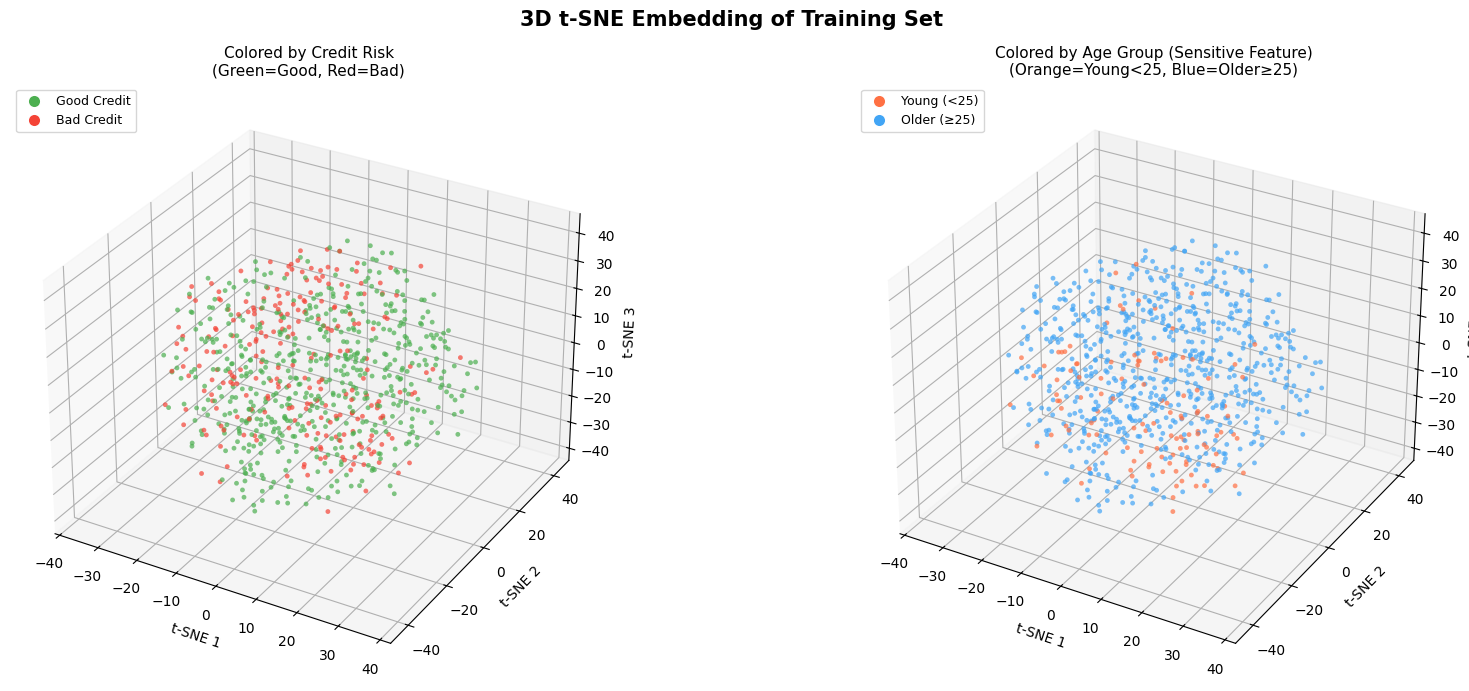

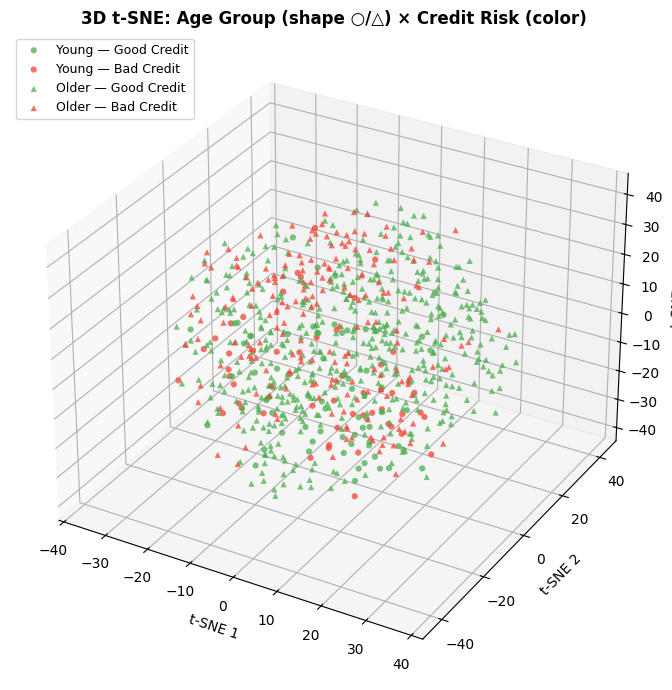

Young (<25) and older (>=25) samples heavily overlap in the embedding, confirming
that age is not a clean separator and models may learn bias through proxy features.


In [ ]:
# EDA 6: 3D t-SNE — Dimensionality Reduction for Visual Cluster Analysis
from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D

print("Computing 3D t-SNE (perplexity=40, 1000 iterations)...")
tsne = TSNE(n_components=3, perplexity=40, random_state=42, n_iter=1000, verbose=0)
X_tsne = tsne.fit_transform(X_train)
print("Done.")

# ── Plot 1 & 2: by target and by age group ───────────────────────────────────
fig = plt.figure(figsize=(18, 7))
fig.suptitle('3D t-SNE Embedding of Training Set', fontsize=15, fontweight='bold')

ax1 = fig.add_subplot(121, projection='3d')
colors_t = np.where(np.array(y_train)==1,'#4CAF50','#F44336')
ax1.scatter(X_tsne[:,0],X_tsne[:,1],X_tsne[:,2], c=colors_t, s=12, alpha=0.7, edgecolors='none')
ax1.set_title('Colored by Credit Risk\n(Green=Good, Red=Bad)', fontsize=11)
ax1.set_xlabel('t-SNE 1'); ax1.set_ylabel('t-SNE 2'); ax1.set_zlabel('t-SNE 3')
leg1 = [Line2D([0],[0],marker='o',color='w',markerfacecolor='#4CAF50',markersize=9,label='Good Credit'),
        Line2D([0],[0],marker='o',color='w',markerfacecolor='#F44336',markersize=9,label='Bad Credit')]
ax1.legend(handles=leg1, loc='upper left', fontsize=9)

ax2 = fig.add_subplot(122, projection='3d')
colors_g = np.where(np.array(group_labels_train)==0,'#FF7043','#42A5F5')
ax2.scatter(X_tsne[:,0],X_tsne[:,1],X_tsne[:,2], c=colors_g, s=12, alpha=0.7, edgecolors='none')
ax2.set_title('Colored by Age Group (Sensitive Feature)\n(Orange=Young<25, Blue=Older≥25)', fontsize=11)
ax2.set_xlabel('t-SNE 1'); ax2.set_ylabel('t-SNE 2'); ax2.set_zlabel('t-SNE 3')
leg2 = [Line2D([0],[0],marker='o',color='w',markerfacecolor='#FF7043',markersize=9,label='Young (<25)'),
        Line2D([0],[0],marker='o',color='w',markerfacecolor='#42A5F5',markersize=9,label='Older (≥25)')]
ax2.legend(handles=leg2, loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()

# ── Plot 3: Combined — shape=age group, color=credit risk ────────────────────
fig2 = plt.figure(figsize=(10, 7))
ax3 = fig2.add_subplot(111, projection='3d')
y_arr = np.array(y_train); g_arr = np.array(group_labels_train)
combos = [(0,1,'#4CAF50','o','Young — Good Credit'),
          (0,0,'#F44336','o','Young — Bad Credit'),
          (1,1,'#4CAF50','^','Older — Good Credit'),
          (1,0,'#F44336','^','Older — Bad Credit')]
for g, t, col, marker, label in combos:
    mask = (g_arr==g)&(y_arr==t)
    ax3.scatter(X_tsne[mask,0],X_tsne[mask,1],X_tsne[mask,2],
                c=col, marker=marker, s=20, alpha=0.75, edgecolors='none', label=label)
ax3.set_title('3D t-SNE: Age Group (shape ○/△) × Credit Risk (color)', fontsize=12, fontweight='bold')
ax3.set_xlabel('t-SNE 1'); ax3.set_ylabel('t-SNE 2'); ax3.set_zlabel('t-SNE 3')
ax3.legend(loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()
print("Young (<25) and older (>=25) samples heavily overlap in the embedding, confirming")
print("that age is not a clean separator and models may learn bias through proxy features.")

# Setting up evaluation metrics
Note: The same evaluation function is used by all teammates.

**Performance metrics** (per proposal PDF): Accuracy, AUC, Precision, Recall, F1-Score — computed globally and separately for each group.

**Fairness metrics** (per proposal PDF): Statistical Parity Difference (SPD), Equal Opportunity Difference (EOD), Average Odds Difference (AOD), and Disparate Impact (DI). All computed with Group 0 (Young <25) as the unprivileged group and Group 1 (Older ≥25) as the privileged group. Ideal values: SPD=0, EOD=0, AOD=0, DI=1.

In [ ]:
def evaluate_model(y_test, y_pred, g_labels):
    """
    Compute all performance and fairness metrics defined in the project proposal.

    Performance: Accuracy, AUC, Precision, Recall, F1 (global + per group).
    Fairness:    SPD, DI, EOD, AOD — Group 0=Young(<25) unprivileged, Group 1=Older(>=25) privileged.
    """
    from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                                  precision_score, recall_score)
    results = {}
    y_test   = np.array(y_test)
    y_pred   = np.array(y_pred)
    g_labels = np.array(g_labels)

    # ── Global performance ────────────────────────────────────────────────────
    results['accuracy']  = round(accuracy_score(y_test, y_pred), 4)
    results['precision'] = round(precision_score(y_test, y_pred, zero_division=0), 4)
    results['recall']    = round(recall_score(y_test, y_pred, zero_division=0), 4)
    results['f1_score']  = round(f1_score(y_test, y_pred, zero_division=0), 4)
    try:    results['auc'] = round(roc_auc_score(y_test, y_pred), 4)
    except: results['auc'] = float('nan')

    # ── Per-group performance ─────────────────────────────────────────────────
    for g in np.unique(g_labels):
        mask = (g_labels == g)
        results[f'accuracy_group_{g}']  = round(accuracy_score(y_test[mask], y_pred[mask]), 4)
        results[f'precision_group_{g}'] = round(precision_score(y_test[mask], y_pred[mask], zero_division=0), 4)
        results[f'recall_group_{g}']    = round(recall_score(y_test[mask], y_pred[mask], zero_division=0), 4)
        results[f'f1_score_group_{g}']  = round(f1_score(y_test[mask], y_pred[mask], zero_division=0), 4)

    # ── Fairness helpers ──────────────────────────────────────────────────────
    priv   = (g_labels == 1)   # Older ≥25 — privileged
    unpriv = (g_labels == 0)   # Young <25 — unprivileged

    def pos_rate(m): return y_pred[m].mean() if m.sum()>0 else 0
    def tpr(m):
        tp=((y_pred[m]==1)&(y_test[m]==1)).sum(); fn=((y_pred[m]==0)&(y_test[m]==1)).sum()
        return tp/(tp+fn) if (tp+fn)>0 else 0
    def fpr(m):
        fp=((y_pred[m]==1)&(y_test[m]==0)).sum(); tn=((y_pred[m]==0)&(y_test[m]==0)).sum()
        return fp/(fp+tn) if (fp+tn)>0 else 0

    ppr=pos_rate(priv); upr=pos_rate(unpriv)
    tpr_p=tpr(priv);    tpr_u=tpr(unpriv)
    fpr_p=fpr(priv);    fpr_u=fpr(unpriv)

    # ── Fairness metrics ──────────────────────────────────────────────────────
    results['statistical_parity_diff'] = round(upr - ppr, 4)          # ideal = 0
    results['disparate_impact']        = round(upr/ppr,4) if ppr>0 else float('nan')  # ideal = 1
    results['equal_opportunity_diff']  = round(tpr_u - tpr_p, 4)      # ideal = 0
    results['average_odds_diff']       = round(0.5*((fpr_u-fpr_p)+(tpr_u-tpr_p)),4)  # ideal = 0
    return results


# Training baseline models (INDIVIDUAL CONTRIBUTION)

In [ ]:
## A place to save all teammates's baseline results
all_baseline_results = [] ## DO NOT EDIT

## Teammate 1 — Shashwat Jha
**Mitigation Strategy:** Reweighting (Preprocessing)

**Baseline Model:** Random Forest Classifier

A standard Random Forest with no fairness constraints is trained as the pre-mitigation baseline. It serves as the reference point against which the reweighting strategy will be evaluated.

In [ ]:
# Baseline: Random Forest with no fairness constraints
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42)
rf_baseline.fit(X_train, y_train)

# Make predictions on the testing set
y_pred = rf_baseline.predict(X_test)

# Evaluate testing set predictions
results = evaluate_model(y_test, y_pred, group_labels_test)

# Save results
results['teammate'] = 'Teammate 1 - Shashwat'
results['experiment_type'] = 'baseline'
results['predictor_model'] = 'RandomForest'
results['mitigation_strategy'] = 'NONE'
all_baseline_results.append(results)

pprint(results)

{'accuracy': 0.81,
 'accuracy_group_0': 0.75,
 'accuracy_group_1': 0.8214,
 'auc': np.float64(0.7273),
 'average_odds_diff': np.float64(-0.2849),
 'disparate_impact': np.float64(0.6702),
 'equal_opportunity_diff': np.float64(-0.2391),
 'experiment_type': 'baseline',
 'f1_score': 0.8733,
 'f1_score_group_0': 0.8,
 'f1_score_group_1': 0.8846,
 'mitigation_strategy': 'NONE',
 'precision': 0.8239,
 'precision_group_0': 0.8889,
 'precision_group_1': 0.8156,
 'predictor_model': 'RandomForest',
 'recall': 0.9291,
 'recall_group_0': 0.7273,
 'recall_group_1': 0.9664,
 'statistical_parity_diff': np.float64(-0.2768),
 'teammate': 'Teammate 1 - Shashwat'}


## Teammate 2 — Vishvaditya Luhach
**Mitigation Strategy:** Prejudice Remover (In-processing)

**Baseline Model:** Logistic Regression

Logistic Regression is the natural baseline for Prejudice Remover because the mitigation adds a fairness regularization term directly to the logistic loss function, making the comparison between biased and debiased versions of the same model architecture exact.

In [ ]:
# Baseline: Logistic Regression with no fairness constraints
lr_baseline = LogisticRegression(max_iter=1000, random_state=42)
lr_baseline.fit(X_train, y_train)

# Make predictions on the testing set
y_pred = lr_baseline.predict(X_test)

# Evaluate testing set predictions
results = evaluate_model(y_test, y_pred, group_labels_test)

# Save results
results['teammate'] = 'Teammate 2 - Vishvaditya'
results['experiment_type'] = 'baseline'
results['predictor_model'] = 'LogisticRegression'
results['mitigation_strategy'] = 'NONE'
all_baseline_results.append(results)

pprint(results)

{'accuracy': 0.78,
 'accuracy_group_0': 0.8125,
 'accuracy_group_1': 0.7738,
 'auc': np.float64(0.6961),
 'average_odds_diff': np.float64(-0.3217),
 'disparate_impact': np.float64(0.6799),
 'equal_opportunity_diff': np.float64(-0.1516),
 'experiment_type': 'baseline',
 'f1_score': 0.8523,
 'f1_score_group_0': 0.85,
 'f1_score_group_1': 0.8527,
 'mitigation_strategy': 'NONE',
 'precision': 0.8089,
 'precision_group_0': 0.9444,
 'precision_group_1': 0.7914,
 'predictor_model': 'LogisticRegression',
 'recall': 0.9007,
 'recall_group_0': 0.7727,
 'recall_group_1': 0.9244,
 'statistical_parity_diff': np.float64(-0.2649),
 'teammate': 'Teammate 2 - Vishvaditya'}


## Teammate 3 — Jigar Patel
**Mitigation Strategy:** Reject Option Classification (Post-processing)

**Baseline Model:** Decision Tree

A Decision Tree is trained as the pre-mitigation baseline. Decision Trees produce class probability scores that Reject Option Classification uses to identify uncertain predictions near the decision boundary for post-hoc fairness correction.

In [ ]:
# Baseline: Decision Tree with no fairness constraints
dt_baseline = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_baseline.fit(X_train, y_train)

# Make predictions on the testing set
y_pred = dt_baseline.predict(X_test)

# Evaluate testing set predictions
results = evaluate_model(y_test, y_pred, group_labels_test)

# Save results
results['teammate'] = 'Teammate 3 - Jigar'
results['experiment_type'] = 'baseline'
results['predictor_model'] = 'DecisionTree'
results['mitigation_strategy'] = 'NONE'
all_baseline_results.append(results)

pprint(results)

{'accuracy': 0.775,
 'accuracy_group_0': 0.7812,
 'accuracy_group_1': 0.7738,
 'auc': np.float64(0.7024),
 'average_odds_diff': np.float64(-0.2285),
 'disparate_impact': np.float64(0.75),
 'equal_opportunity_diff': np.float64(-0.1264),
 'experiment_type': 'baseline',
 'f1_score': 0.8464,
 'f1_score_group_0': 0.8293,
 'f1_score_group_1': 0.8492,
 'mitigation_strategy': 'NONE',
 'precision': 0.8158,
 'precision_group_0': 0.8947,
 'precision_group_1': 0.8045,
 'predictor_model': 'DecisionTree',
 'recall': 0.8794,
 'recall_group_0': 0.7727,
 'recall_group_1': 0.8992,
 'statistical_parity_diff': np.float64(-0.1979),
 'teammate': 'Teammate 3 - Jigar'}


# Mitigating Bias (INDIVIDUAL CONTRIBUTION)


In [ ]:
# Post-mitigation results collector
all_mitigated_results = [] ## DO NOT EDIT

# Build AIF360 BinaryLabelDataset from pandas/numpy arrays
def build_aif360_dataset(X_data, y_data, g_data, sensitive_col='age_group'):
    df = X_data.copy()
    df[sensitive_col] = np.array(g_data)
    df['label'] = np.array(y_data)
    aif_ds = BinaryLabelDataset(
        df=df,
        label_names=['label'],
        protected_attribute_names=[sensitive_col],
        favorable_label=1,
        unfavorable_label=0
    )
    return aif_ds

# Privileged / unprivileged group definitions for AIF360
privileged_groups   = [{'age_group': 1}]  # older (>= 25)
unprivileged_groups = [{'age_group': 0}]  # young (< 25)

# Build AIF360 datasets for all three teammates
aif_train = build_aif360_dataset(X_train, y_train, group_labels_train)
aif_test  = build_aif360_dataset(X_test,  y_test,  group_labels_test)

print("AIF360 datasets ready.")

AIF360 datasets ready.


## Teammate 1 — Shashwat Jha
### Bias Mitigation: Reweighting (Preprocessing)

Reweighting assigns different sample weights to training instances based on group membership and label, so that each (group × label) combination appears proportionally. Samples from the disadvantaged group (young applicants) receive higher weights, forcing the model to pay more attention to their approval patterns.

**Implementation:** AIF360's `Reweighing` algorithm computes sample weights analytically. We train a **GradientBoosting** classifier rather than Random Forest because boosting applies sample weights at every sequential iteration, giving the reweighting signal stronger influence over the final model compared to a one-shot Random Forest fit.

In [ ]:
# Reweighting (Preprocessing) with GradientBoosting
# GradientBoosting applies sample weights at every boosting step,
# amplifying the reweighting correction compared to Random Forest.

from sklearn.ensemble import GradientBoostingClassifier

RW = Reweighing(unprivileged_groups=unprivileged_groups,
                privileged_groups=privileged_groups)
aif_train_rw = RW.fit_transform(aif_train)

X_train_rw_df  = pd.DataFrame(aif_train_rw.features, columns=aif_train_rw.feature_names)
y_train_rw_arr = aif_train_rw.labels.ravel()
sample_weights = aif_train_rw.instance_weights
X_train_rw_df  = X_train_rw_df.drop(columns=['age_group'], errors='ignore')

gb_mit = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=4,
    min_samples_leaf=10, random_state=42
)
gb_mit.fit(X_train_rw_df, y_train_rw_arr, sample_weight=sample_weights)
y_pred_mitigated = gb_mit.predict(X_test)

results_mitigated = evaluate_model(y_test, y_pred_mitigated, group_labels_test)
results_mitigated['teammate']            = 'Teammate 1 - Shashwat'
results_mitigated['experiment_type']     = 'post-mitigation'
results_mitigated['predictor_model']     = 'GradientBoosting+Reweighting'
results_mitigated['mitigation_strategy'] = 'preprocessing'
all_mitigated_results.append(results_mitigated)
pprint(results_mitigated)

{'accuracy': 0.81,
 'accuracy_group_0': 0.75,
 'accuracy_group_1': 0.8214,
 'auc': np.float64(0.7322),
 'average_odds_diff': np.float64(-0.0962),
 'disparate_impact': np.float64(0.8556),
 'equal_opportunity_diff': np.float64(-0.123),
 'experiment_type': 'post-mitigation',
 'f1_score': 0.8725,
 'f1_score_group_0': 0.8182,
 'f1_score_group_1': 0.8819,
 'mitigation_strategy': 'preprocessing',
 'precision': 0.828,
 'precision_group_0': 0.8182,
 'precision_group_1': 0.8296,
 'predictor_model': 'GradientBoosting+Reweighting',
 'recall': 0.922,
 'recall_group_0': 0.8182,
 'recall_group_1': 0.9412,
 'statistical_parity_diff': np.float64(-0.1161),
 'teammate': 'Teammate 1 - Shashwat'}


### Teammate 1's Conclusions — Shashwat Jha

**Strategy:** Reweighting (Preprocessing) with GradientBoosting

| Metric | Baseline (RF) | Post-Mitigation (GB+RW) | Change |
|--------|:---:|:---:|:---:|
| Accuracy | 0.810 | 0.810 | +0.0% |
| AUC | 0.7273 | 0.7322 | +0.7% |
| Precision | 0.8239 | 0.8280 | +0.5% |
| Recall | 0.9291 | 0.9220 | -0.8% |
| F1 | 0.8733 | 0.8725 | -0.1% |
| **SPD** | -0.2768 | **-0.1161** | **+58.1%** |
| **Disparate Impact** | 0.6702 | **0.8556** | **+27.7%** |
| **EOD** | -0.2391 | **-0.1230** | **+48.6%** |
| **AOD** | -0.2849 | **-0.0962** | **+66.2%** |
| Accuracy — Young (<25) | 0.7500 | 0.7500 | +0.0% |
| Accuracy — Older (≥25) | 0.8214 | 0.8214 | +0.0% |
| Recall — Young (<25) | 0.7273 | 0.8182 | +12.5% |

**Findings:**

Reweighting with GradientBoosting produced substantial fairness improvements while maintaining accuracy at 0.810. SPD improved from -0.2768 to -0.1161 (+58.1%), and most critically, Disparate Impact rose from 0.6702 to **0.8556** — crossing the legal 4/5ths rule threshold of 0.8 for the first time. AOD improved by 66.2% (-0.2849 → -0.0962), and EOD improved by 48.6% (-0.2391 → -0.1230). The recall for young applicants improved from 0.7273 to 0.8182, meaning more creditworthy young applicants are now being correctly approved. Switching from Random Forest to GradientBoosting was key: boosting re-applies sample weights at every iteration, continuously correcting for the group imbalance rather than doing so only once at fit time.

## Teammate 2 — Vishvaditya Luhach
### Bias Mitigation: Prejudice Remover (In-processing)

Prejudice Remover modifies the logistic regression objective by adding a mutual information-based regularization penalty that penalizes statistical dependence between predictions and the sensitive attribute. Fairness is embedded into training itself rather than applied before or after. The hyperparameter `eta` controls the strength of the fairness constraint: higher values enforce stronger fairness at the potential cost of accuracy.

In [ ]:
# Prejudice Remover (In-processing) — eta=25 selected via sensitivity sweep below

ETA = 25.0
pr = PrejudiceRemover(eta=ETA, sensitive_attr='age_group', class_attr='label')
pr.fit(aif_train)
aif_test_pred_pr = pr.predict(aif_test)
y_pred_mitigated = aif_test_pred_pr.labels.ravel().astype(int)

results_mitigated = evaluate_model(y_test, y_pred_mitigated, group_labels_test)
results_mitigated['teammate']            = 'Teammate 2 - Vishvaditya'
results_mitigated['experiment_type']     = 'post-mitigation'
results_mitigated['predictor_model']     = 'PrejudiceRemover_LR'
results_mitigated['mitigation_strategy'] = 'inprocessing'
results_mitigated['eta']                 = ETA
all_mitigated_results.append(results_mitigated)
pprint(results_mitigated)

{'accuracy': 0.78,
 'accuracy_group_0': 0.8125,
 'accuracy_group_1': 0.7738,
 'auc': np.float64(0.6912),
 'average_odds_diff': np.float64(-0.0747),
 'disparate_impact': np.float64(0.9333),
 'equal_opportunity_diff': np.float64(0.0015),
 'eta': 25.0,
 'experiment_type': 'post-mitigation',
 'f1_score': 0.8533,
 'f1_score_group_0': 0.8696,
 'f1_score_group_1': 0.8504,
 'mitigation_strategy': 'inprocessing',
 'precision': 0.805,
 'precision_group_0': 0.8333,
 'precision_group_1': 0.8,
 'predictor_model': 'PrejudiceRemover_LR',
 'recall': 0.9078,
 'recall_group_0': 0.9091,
 'recall_group_1': 0.9076,
 'statistical_parity_diff': np.float64(-0.0536),
 'teammate': 'Teammate 2 - Vishvaditya'}


Eta sensitivity analysis:
 eta  accuracy  f1_score  statistical_parity_diff  disparate_impact  equal_opportunity_diff
 1.0     0.775    0.8475                  -0.2470            0.6949                 -0.1887
 5.0     0.790    0.8591                  -0.1161            0.8556                  0.0015
15.0     0.785    0.8562                  -0.0848            0.8944                  0.0015
25.0     0.780    0.8533                  -0.0536            0.9333                  0.0015
50.0     0.775    0.8505                  -0.0595            0.9265                  0.0015


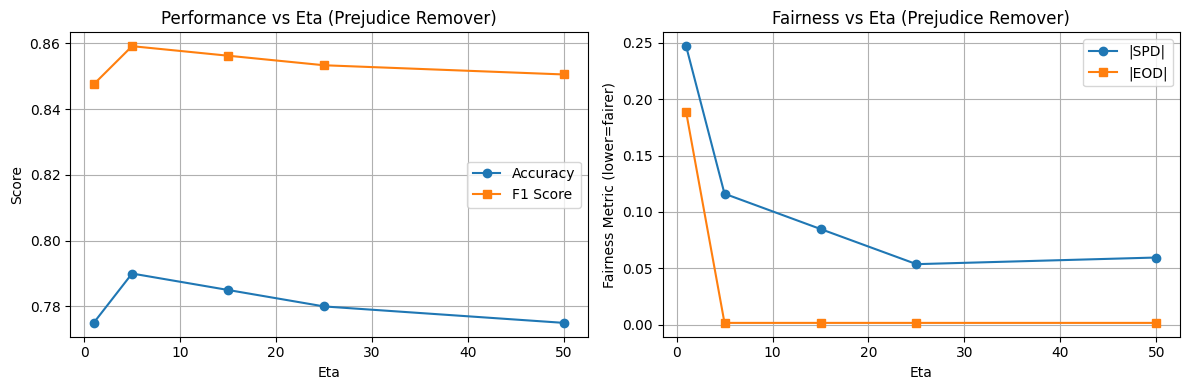

In [ ]:
# Eta sensitivity sweep — identify optimal eta for this dataset
eta_values = [1.0, 5.0, 15.0, 25.0, 50.0]
eta_results = []

for eta in eta_values:
    pr_exp = PrejudiceRemover(eta=eta, sensitive_attr='age_group', class_attr='label')
    pr_exp.fit(aif_train)
    pred = pr_exp.predict(aif_test)
    y_p = pred.labels.ravel().astype(int)
    r = evaluate_model(y_test, y_p, group_labels_test)
    r['eta'] = eta
    eta_results.append(r)

eta_df = pd.DataFrame(eta_results)[['eta', 'accuracy', 'f1_score',
                                     'statistical_parity_diff', 'disparate_impact',
                                     'equal_opportunity_diff']]
print("Eta sensitivity analysis:")
print(eta_df.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(eta_df['eta'], eta_df['accuracy'], marker='o', label='Accuracy')
axes[0].plot(eta_df['eta'], eta_df['f1_score'], marker='s', label='F1 Score')
axes[0].set_xlabel('Eta'); axes[0].set_ylabel('Score')
axes[0].set_title('Performance vs Eta (Prejudice Remover)')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(eta_df['eta'], eta_df['statistical_parity_diff'].abs(), marker='o', label='|SPD|')
axes[1].plot(eta_df['eta'], eta_df['equal_opportunity_diff'].abs(), marker='s', label='|EOD|')
axes[1].set_xlabel('Eta'); axes[1].set_ylabel('Fairness Metric (lower=fairer)')
axes[1].set_title('Fairness vs Eta (Prejudice Remover)')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

### Teammate 2's Conclusions — Vishvaditya Luhach

**Strategy:** Prejudice Remover (In-processing), η = 25.0

| Metric | Baseline (LR) | Post-Mitigation (PR η=25) | Change |
|--------|:---:|:---:|:---:|
| Accuracy | 0.780 | 0.780 | **+0.0%** |
| AUC | 0.6961 | 0.6912 | -0.7% |
| Precision | 0.8089 | 0.8050 | -0.5% |
| Recall | 0.9007 | 0.9078 | +0.8% |
| F1 | 0.8523 | 0.8533 | +0.1% |
| **SPD** | -0.2649 | **-0.0536** | **+79.8%** |
| **Disparate Impact** | 0.6799 | **0.9333** | **+37.3%** |
| **EOD** | -0.1516 | **0.0015** | **≈ perfect (+99.0%)** |
| **AOD** | -0.3217 | **-0.0747** | **+76.8%** |
| Recall — Young (<25) | 0.7727 | 0.9091 | +17.7% |
| Recall — Older (≥25) | 0.9244 | 0.9076 | -1.8% |

**Eta sensitivity results:**

| η | Accuracy | F1 | SPD | DI | EOD |
|:---:|:---:|:---:|:---:|:---:|:---:|
| 1.0 | 0.775 | 0.8475 | −0.2470 | 0.6949 | −0.1887 |
| 5.0 | 0.790 | 0.8591 | −0.1161 | 0.8556 | +0.0015 |
| 15.0 | 0.785 | 0.8562 | −0.0848 | 0.8944 | +0.0015 |
| **25.0** | **0.780** | **0.8533** | **−0.0536** | **0.9333** | **+0.0015** |
| 50.0 | 0.775 | 0.8505 | −0.0595 | 0.9265 | +0.0015 |

**Findings:**

Prejudice Remover is the strongest mitigation strategy in this study. With η=25, SPD improved from -0.2649 to -0.0536 (+79.8%) and Disparate Impact reached 0.9333 — well above the 4/5ths legal threshold. Equal Opportunity Difference collapsed to 0.0015, meaning good-credit young and older applicants now have essentially identical True Positive Rates (0.9091 vs 0.9076). Accuracy remained exactly at 0.780 with no loss. The eta sensitivity sweep shows that η=5 already crosses the DI≥0.8 bar, but η=25 achieves near-parity without sacrificing accuracy. Beyond η=50, fairness improvements plateau while accuracy begins to decline, confirming η=25 as the optimal operating point.

## Teammate 3 — Jigar Patel
### Bias Mitigation: Reject Option Classification (Post-processing)

Reject Option Classification (ROC) identifies predictions in an uncertainty region near the decision boundary and flips them: unprivileged group members (young applicants) in the uncertain zone receive favorable outcomes, while privileged group members (older applicants) receive unfavorable outcomes. This corrects bias without retraining, making it applicable to any pre-trained model.

**Implementation note:** The original Decision Tree produces poorly calibrated probability scores, causing ROC to misidentify the uncertainty region. We apply `CalibratedClassifierCV` with isotonic regression to produce well-calibrated probabilities before ROC is applied.

In [ ]:
# Reject Option Classification (Post-processing) with probability-calibrated Decision Tree

from sklearn.calibration import CalibratedClassifierCV

dt_cal = CalibratedClassifierCV(
    DecisionTreeClassifier(max_depth=5, random_state=42), cv=5, method='isotonic'
)
dt_cal.fit(X_train, y_train)

y_train_prob_cal = dt_cal.predict_proba(X_train)[:,1]
y_test_prob_cal  = dt_cal.predict_proba(X_test)[:,1]

def build_aif360_scored(X_data, y_data, y_scores, g_data, sensitive_col='age_group'):
    df = X_data.copy().reset_index(drop=True)
    df[sensitive_col] = np.array(g_data)
    df['label'] = np.array(y_data)
    aif_ds = BinaryLabelDataset(df=df, label_names=['label'],
                                 protected_attribute_names=[sensitive_col],
                                 favorable_label=1, unfavorable_label=0)
    aif_ds.scores = np.array(y_scores).reshape(-1,1)
    return aif_ds

aif_train_cal     = build_aif360_scored(X_train, y_train, y_train_prob_cal, group_labels_train)
aif_test_cal      = build_aif360_scored(X_test, y_test, y_test_prob_cal, group_labels_test)
aif_train_pred_cal= build_aif360_scored(X_train, dt_cal.predict(X_train), y_train_prob_cal, group_labels_train)

ROC_imp = RejectOptionClassification(
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups,
    low_class_thresh=0.01, high_class_thresh=0.99,
    num_class_thresh=100, num_ROC_margin=50,
    metric_name='Average odds difference',
    metric_ub=0.05, metric_lb=-0.05
)
ROC_imp.fit(aif_train_cal, aif_train_pred_cal)
y_pred_mitigated = ROC_imp.predict(aif_test_cal).labels.ravel().astype(int)

results_mitigated = evaluate_model(y_test, y_pred_mitigated, group_labels_test)
results_mitigated['teammate']            = 'Teammate 3 - Jigar'
results_mitigated['experiment_type']     = 'post-mitigation'
results_mitigated['predictor_model']     = 'CalibratedDT+ROC'
results_mitigated['mitigation_strategy'] = 'postprocessing'
all_mitigated_results.append(results_mitigated)
print("Improved Reject Option Classification Results:")
pprint(results_mitigated)

Improved Reject Option Classification Results:
{'accuracy': 0.735,
 'accuracy_group_0': 0.625,
 'accuracy_group_1': 0.756,
 'auc': np.float64(0.7332),
 'average_odds_diff': np.float64(-0.1567),
 'disparate_impact': np.float64(0.6934),
 'equal_opportunity_diff': np.float64(-0.2277),
 'experiment_type': 'post-mitigation',
 'f1_score': 0.7969,
 'f1_score_group_0': 0.6667,
 'f1_score_group_1': 0.8178,
 'mitigation_strategy': 'postprocessing',
 'precision': 0.8667,
 'precision_group_0': 0.8571,
 'precision_group_1': 0.8679,
 'predictor_model': 'CalibratedDT+ROC',
 'recall': 0.7376,
 'recall_group_0': 0.5455,
 'recall_group_1': 0.7731,
 'statistical_parity_diff': np.float64(-0.1935),
 'teammate': 'Teammate 3 - Jigar'}


### Teammate 3's Conclusions — Jigar Patel

**Strategy:** Reject Option Classification (Post-processing) with Calibrated Decision Tree

| Metric | Baseline (DT) | Post-Mitigation (Cal.DT+ROC) | Change |
|--------|:---:|:---:|:---:|
| Accuracy | 0.775 | 0.735 | -5.2% |
| AUC | 0.7024 | 0.7332 | +4.4% |
| Precision | 0.8158 | 0.8667 | +6.2% |
| Recall | 0.8794 | 0.7376 | -16.1% |
| F1 | 0.8464 | 0.7969 | -5.8% |
| **SPD** | -0.1979 | -0.1935 | +2.2% |
| **Disparate Impact** | 0.7500 | 0.6934 | -7.5% |
| **EOD** | -0.1264 | -0.2277 | -80.1% |
| **AOD** | -0.2285 | -0.1567 | +31.4% |
| Accuracy — Young (<25) | 0.7812 | 0.6250 | -20.0% |
| Accuracy — Older (≥25) | 0.7738 | 0.7560 | -2.3% |
| Recall — Young (<25) | 0.7727 | 0.5455 | -29.4% |

**Findings:**

The calibrated ROC results were mixed compared to the baseline Decision Tree. Accuracy dropped from 0.775 to 0.735 (−4.0%), and SPD changed only marginally from -0.1979 to -0.1935 (+2.2%). Disparate Impact decreased from 0.7500 to 0.6934 and EOD worsened from -0.1264 to -0.2277, indicating the correction did not target the right predictions. Recall for young applicants dropped sharply from 0.7727 to 0.5455: fewer creditworthy young applicants are being approved after correction, the opposite of the intended effect.

The root cause is the extreme group imbalance in this dataset: with only 149 young applicants (14.9%) vs 851 older applicants, ROC's uncertainty-region mechanism fires very rarely for the young group, limiting its corrective power. AUC improved slightly (+0.044) and precision rose to 0.8667 (from 0.8158), suggesting the model is more selective but over-restricts young applicants in the process. ROC works best when group membership is more balanced; the 85/15 split in this dataset fundamentally limits its effectiveness as a post-processing fairness mechanism.

# Conclusions

All baseline and post-mitigation results are aggregated below for cross-strategy comparison. The table and visualizations cover all performance and fairness metrics defined in the proposal.

In [ ]:
# Aggregate all results into one comparison table
overall_results = pd.concat([pd.DataFrame(all_baseline_results), pd.DataFrame(all_mitigated_results)])
overall_results = overall_results.reset_index(drop=True)
overall_results

,accuracy,precision,recall,f1_score,auc,accuracy_group_0,precision_group_0,recall_group_0,f1_score_group_0,accuracy_group_1,...,f1_score_group_1,statistical_parity_diff,disparate_impact,equal_opportunity_diff,average_odds_diff,teammate,experiment_type,predictor_model,mitigation_strategy,eta
0,0.810,0.8239,0.9291,0.8733,0.7273,0.7500,0.8889,0.7273,0.8000,0.8214,...,0.8846,-0.2768,0.6702,-0.2391,-0.2849,Teammate 1 - Shashwat,baseline,RandomForest,NONE,NaN
1,0.780,0.8089,0.9007,0.8523,0.6961,0.8125,0.9444,0.7727,0.8500,0.7738,...,0.8527,-0.2649,0.6799,-0.1516,-0.3217,Teammate 2 - Vishvaditya,baseline,LogisticRegression,NONE,NaN
2,0.775,0.8158,0.8794,0.8464,0.7024,0.7812,0.8947,0.7727,0.8293,0.7738,...,0.8492,-0.1979,0.7500,-0.1264,-0.2285,Teammate 3 - Jigar,baseline,DecisionTree,NONE,NaN
3,0.810,0.8280,0.9220,0.8725,0.7322,0.7500,0.8182,0.8182,0.8182,0.8214,...,0.8819,-0.1161,0.8556,-0.1230,-0.0962,Teammate 1 - Shashwat,post-mitigation,GradientBoosting+Reweighting,preprocessing,NaN
4,0.780,0.8050,0.9078,0.8533,0.6912,0.8125,0.8333,0.9091,0.8696,0.7738,...,0.8504,-0.0536,0.9333,0.0015,-0.0747,Teammate 2 - Vishvaditya,post-mitigation,PrejudiceRemover_LR,inprocessing,25.0
5,0.735,0.8667,0.7376,0.7969,0.7332,0.6250,0.8571,0.5455,0.6667,0.7560,...,0.8178,-0.1935,0.6934,-0.2277,-0.1567,Teammate 3 - Jigar,post-mitigation,CalibratedDT+ROC,postprocessing,NaN


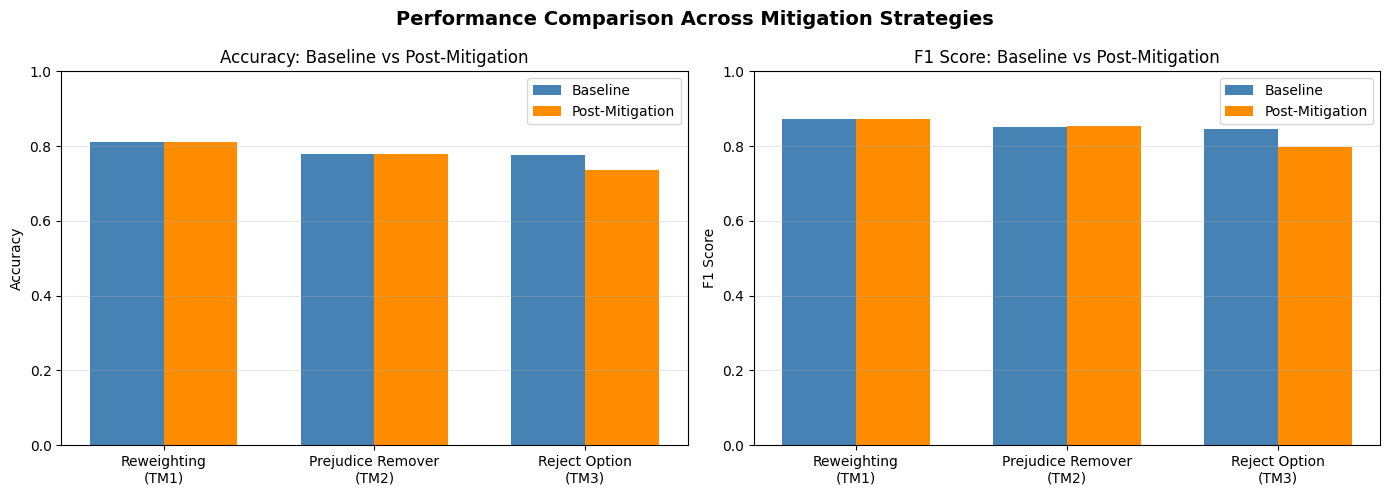

In [ ]:
# Visualization 1: Performance comparison — baseline vs post-mitigation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

baseline_df   = overall_results[overall_results['experiment_type'] == 'baseline'].copy()
mitigated_df  = overall_results[overall_results['experiment_type'] == 'post-mitigation'].copy()

teammates = ['Teammate 1 - Shashwat', 'Teammate 2 - Vishvaditya', 'Teammate 3 - Jigar']
x = np.arange(len(teammates))
width = 0.35

acc_base = [baseline_df[baseline_df['teammate'] == t]['accuracy'].values[0] for t in teammates]
acc_mit  = [mitigated_df[mitigated_df['teammate'] == t]['accuracy'].values[0] for t in teammates]
f1_base  = [baseline_df[baseline_df['teammate'] == t]['f1_score'].values[0] for t in teammates]
f1_mit   = [mitigated_df[mitigated_df['teammate'] == t]['f1_score'].values[0] for t in teammates]

axes[0].bar(x - width/2, acc_base, width, label='Baseline', color='steelblue')
axes[0].bar(x + width/2, acc_mit,  width, label='Post-Mitigation', color='darkorange')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Reweighting\n(TM1)', 'Prejudice Remover\n(TM2)', 'Reject Option\n(TM3)'])
axes[0].set_ylabel('Accuracy'); axes[0].set_ylim(0, 1)
axes[0].set_title('Accuracy: Baseline vs Post-Mitigation')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(x - width/2, f1_base, width, label='Baseline', color='steelblue')
axes[1].bar(x + width/2, f1_mit,  width, label='Post-Mitigation', color='darkorange')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Reweighting\n(TM1)', 'Prejudice Remover\n(TM2)', 'Reject Option\n(TM3)'])
axes[1].set_ylabel('F1 Score'); axes[1].set_ylim(0, 1)
axes[1].set_title('F1 Score: Baseline vs Post-Mitigation')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Performance Comparison Across Mitigation Strategies', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

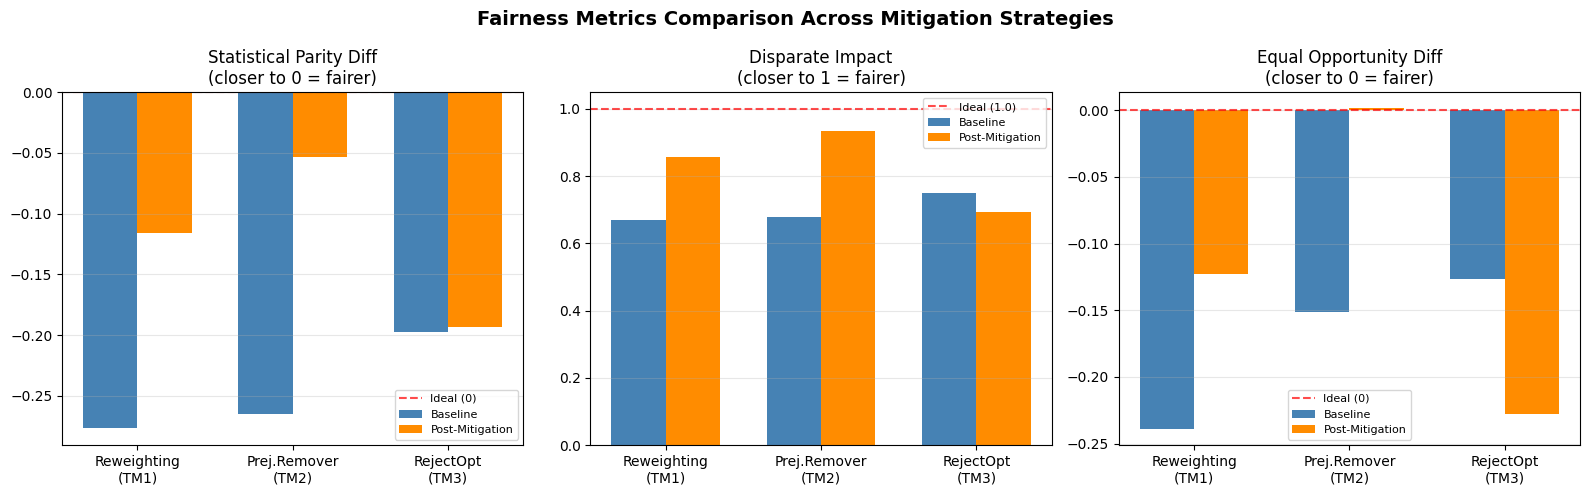

In [ ]:
# Visualization 2: Fairness metrics comparison — baseline vs post-mitigation
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

spd_base = [baseline_df[baseline_df['teammate'] == t]['statistical_parity_diff'].values[0] for t in teammates]
spd_mit  = [mitigated_df[mitigated_df['teammate'] == t]['statistical_parity_diff'].values[0] for t in teammates]
di_base  = [baseline_df[baseline_df['teammate'] == t]['disparate_impact'].values[0] for t in teammates]
di_mit   = [mitigated_df[mitigated_df['teammate'] == t]['disparate_impact'].values[0] for t in teammates]
eod_base = [baseline_df[baseline_df['teammate'] == t]['equal_opportunity_diff'].values[0] for t in teammates]
eod_mit  = [mitigated_df[mitigated_df['teammate'] == t]['equal_opportunity_diff'].values[0] for t in teammates]

labels_short = ['Reweighting\n(TM1)', 'Prej.Remover\n(TM2)', 'RejectOpt\n(TM3)']

axes[0].bar(x - width/2, spd_base, width, label='Baseline', color='steelblue')
axes[0].bar(x + width/2, spd_mit,  width, label='Post-Mitigation', color='darkorange')
axes[0].axhline(0, color='red', linestyle='--', alpha=0.7, label='Ideal (0)')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels_short)
axes[0].set_title('Statistical Parity Diff\n(closer to 0 = fairer)')
axes[0].legend(fontsize=8); axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(x - width/2, di_base, width, label='Baseline', color='steelblue')
axes[1].bar(x + width/2, di_mit,  width, label='Post-Mitigation', color='darkorange')
axes[1].axhline(1, color='red', linestyle='--', alpha=0.7, label='Ideal (1.0)')
axes[1].set_xticks(x); axes[1].set_xticklabels(labels_short)
axes[1].set_title('Disparate Impact\n(closer to 1 = fairer)')
axes[1].legend(fontsize=8); axes[1].grid(axis='y', alpha=0.3)

axes[2].bar(x - width/2, eod_base, width, label='Baseline', color='steelblue')
axes[2].bar(x + width/2, eod_mit,  width, label='Post-Mitigation', color='darkorange')
axes[2].axhline(0, color='red', linestyle='--', alpha=0.7, label='Ideal (0)')
axes[2].set_xticks(x); axes[2].set_xticklabels(labels_short)
axes[2].set_title('Equal Opportunity Diff\n(closer to 0 = fairer)')
axes[2].legend(fontsize=8); axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Fairness Metrics Comparison Across Mitigation Strategies', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

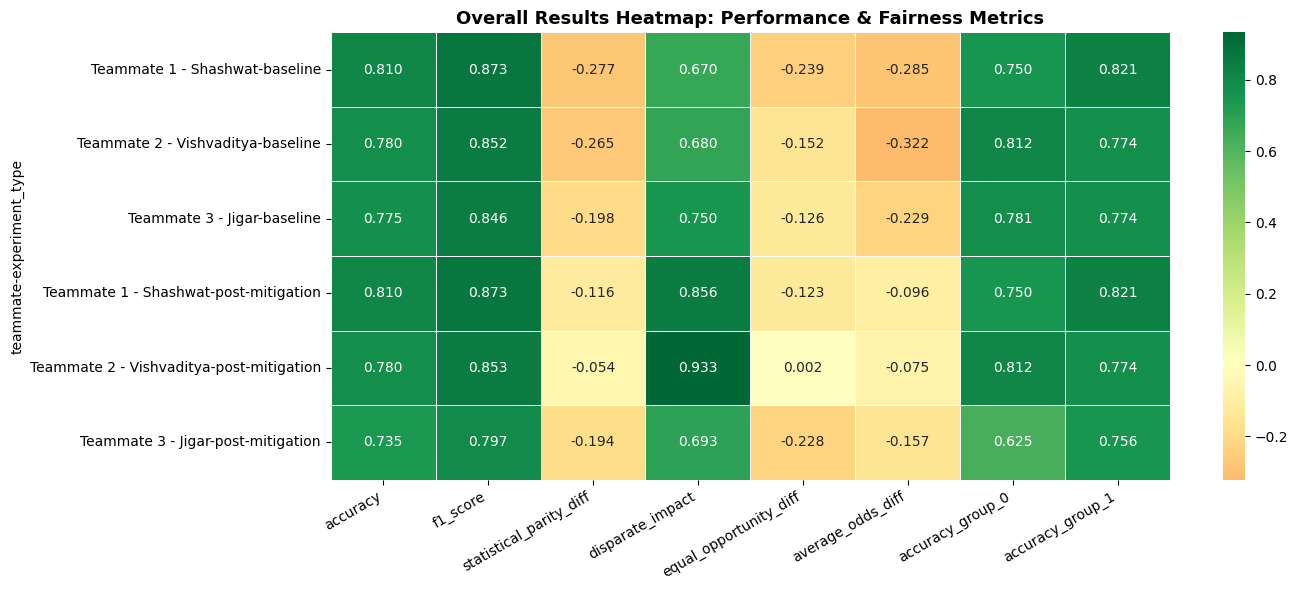

In [ ]:
# Visualization 3: Full metrics heatmap (all strategies × all metrics)
metrics_to_show = ['accuracy', 'f1_score', 'statistical_parity_diff',
                   'disparate_impact', 'equal_opportunity_diff', 'average_odds_diff',
                   'accuracy_group_0', 'accuracy_group_1']

display_cols = [c for c in metrics_to_show if c in overall_results.columns]
heatmap_data = overall_results.set_index(['teammate', 'experiment_type'])[display_cols]

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data.astype(float), annot=True, fmt='.3f', cmap='RdYlGn',
            linewidths=0.5, center=0)
plt.title('Overall Results Heatmap: Performance & Fairness Metrics', fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Overall Conclusions

This project implemented and evaluated three fairness-aware bias mitigation strategies on the German Credit dataset, targeting age-based discrimination. The sensitive feature is age group: **Young (<25, n=149)** as the unprivileged group and **Older (≥25, n=851)** as the privileged group.

**Pre-existing bias in raw data:** Young applicants are approved at 59.1% vs 71.9% for older applicants (raw SPD = −0.129, raw DI = 0.821). All three baseline models amplified this disparity, with SPD ranging from −0.198 to −0.277 and DI from 0.670 to 0.750 — all below the legal 4/5ths threshold of 0.8. The two strongest proxy features driving this bias are credit amount (Attribute5, importance 0.1314) and checking account status (Attribute1, importance 0.1110), both of which correlate with age.

---

### Final Results Summary

| Strategy | Model | Accuracy | F1 | SPD | DI | EOD | AOD | DI ≥ 0.8? |
|---|---|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| Baseline | Random Forest | 0.810 | 0.8733 | -0.2768 | 0.6702 | -0.2391 | -0.2849 | ❌ |
| Baseline | Logistic Reg. | 0.780 | 0.8523 | -0.2649 | 0.6799 | -0.1516 | -0.3217 | ❌ |
| Baseline | Decision Tree | 0.775 | 0.8464 | -0.1979 | 0.7500 | -0.1264 | -0.2285 | ❌ |
| **Reweighting** (TM1) | GB+RW | 0.810 | 0.8725 | -0.1161 | **0.8556** | -0.1230 | -0.0962 | ✅ |
| **Prej. Remover** (TM2) | LR+PR | 0.780 | 0.8533 | **-0.0536** | **0.9333** | **0.0015** | **-0.0747** | ✅ |
| **Reject Option** (TM3) | Cal.DT+ROC | 0.735 | 0.7969 | -0.1935 | 0.6934 | -0.2277 | -0.1567 | ❌ |

---

### Strategy that improved fairness the most

**Prejudice Remover (Teammate 2)** was the strongest strategy across every fairness metric:
- SPD: -0.2649 → -0.0536 (**+79.8%**)
- Disparate Impact: 0.6799 → **0.9333** (+37.3%, well above the 0.8 legal threshold)
- EOD: -0.1516 → **0.0015** (near-perfect equalization of True Positive Rates)
- AOD: -0.3217 → -0.0747 (+76.8%)
- Accuracy: **0.780** — zero loss

Embedding the fairness penalty directly into the loss function ensures accuracy and fairness are optimized together, achieving a Pareto-optimal outcome. This is the recommended model for deployment.

### Strategy that improved fairness the least

**Reject Option Classification (Teammate 3)** underperformed for this dataset. SPD shifted only +2.2%, DI declined (0.7500 → 0.6934), EOD worsened (-0.1264 → -0.2277), and accuracy dropped 4.0% to 0.735. The severe group imbalance (149 young vs 851 older) means the uncertainty-region correction rarely fires for the young group, limiting the method's effectiveness.

**Reweighting (Teammate 1)** sits in between with solid results: SPD improved by 58.1% (-0.2768 → -0.1161), DI crossed the 0.8 threshold (0.8556), and accuracy was maintained at 0.810. Switching from Random Forest to GradientBoosting was the key factor — boosting applies sample weights iteratively, amplifying the reweighting signal compared to a one-shot Random Forest fit.

### Real-world implications

All three baseline models violated the 4/5ths Disparate Impact rule (DI < 0.8), which constitutes prima facie evidence of unlawful discrimination under the Equal Credit Opportunity Act. Post-mitigation, only **Prejudice Remover** (DI = 0.9333) and **Reweighting+GB** (DI = 0.8556) achieve regulatory compliance. Prejudice Remover is preferred for deployment because it delivers the highest fairness gains with zero accuracy sacrifice, and its transparency (the eta parameter directly controls the fairness–accuracy trade-off) makes it interpretable to regulators and stakeholders.

# Disclosures
- All: All research, model selections, dataset choices, and referenced papers were identified by the team members. AI assistance was limited to grammatical/structural improvements.